# CELL 1: IMPORT LIBRARIES

In [1]:
!pip install shap
!pip install xgboost
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, mean_squared_error,
    mean_absolute_error, classification_report, silhouette_score,
    confusion_matrix, roc_curve, r2_score
)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

from xgboost import XGBClassifier, XGBRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 2. LOAD DATA

In [3]:
df = pd.read_csv("/content/bank_additional_with_sim_clv.csv")

print("Shape:", df.shape)
print(df.head())
print(df.info())

Shape: (41188, 30)
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...   y  y_bin  engagement_score  customer_segment  \
0   may         mon  ...  no      0              7.99                 3   
1   may         mon  ...  no      0              5.77                 2   
2   may         mon  ...  no      0              7.29                 3   
3   may         mon  ...  no      0              5.81                 3   
4   may         mon  ...  no      0              8.90                 3   

  monthly_value_sim  retention_months_sim  discount_rate_sim  churn_prob_

# 3. BASIC CLEANING

In [4]:
if 'y' in df.columns:
    df['y_bin'] = (df['y'].astype(str).str.lower() == 'yes').astype(int)

# Check missing values
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(20))

Series([], dtype: int64)


# 4. QUICK EDA

               age      duration      campaign      previous  \
count  41188.00000  41188.000000  41188.000000  41188.000000   
mean      40.02406    258.285010      2.567593      0.172963   
std       10.42125    259.279249      2.770014      0.494901   
min       17.00000      0.000000      1.000000      0.000000   
25%       32.00000    102.000000      1.000000      0.000000   
50%       38.00000    180.000000      2.000000      0.000000   
75%       47.00000    319.000000      3.000000      0.000000   
max       98.00000   4918.000000     56.000000      7.000000   

       engagement_score       clv_sim  
count      41188.000000  41188.000000  
mean           8.268468   2319.415135  
std            7.302703   3903.331646  
min            0.000000      0.830000  
25%            4.020000    512.012500  
50%            5.780000   1119.590000  
75%            9.290000   2347.245000  
max          100.000000  64868.020000  


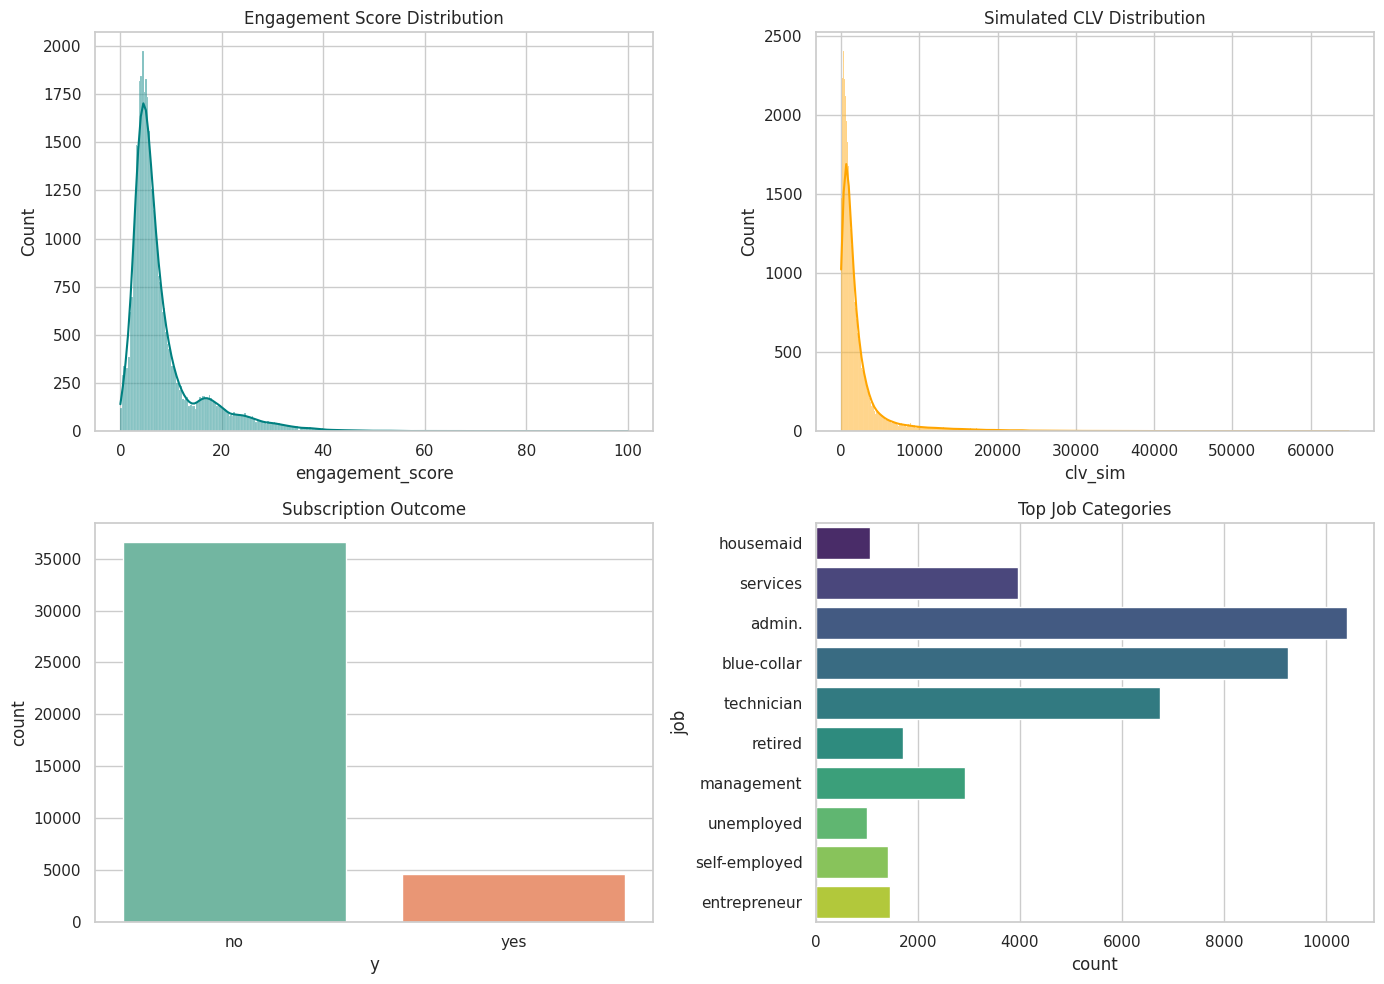

In [5]:
print(df[['age', 'duration', 'campaign', 'previous', 'engagement_score', 'clv_sim']].describe())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['engagement_score'], kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title("Engagement Score Distribution")

sns.histplot(df['clv_sim'], kde=True, ax=axes[0, 1], color='orange')
axes[0, 1].set_title("Simulated CLV Distribution")

sns.countplot(x='y', data=df, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title("Subscription Outcome")

top_jobs = df['job'].value_counts().index[:10]
sns.countplot(y='job', data=df[df['job'].isin(top_jobs)], ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title("Top Job Categories")

plt.tight_layout()
plt.show()

# 5. CUSTOMER SEGMENTATION

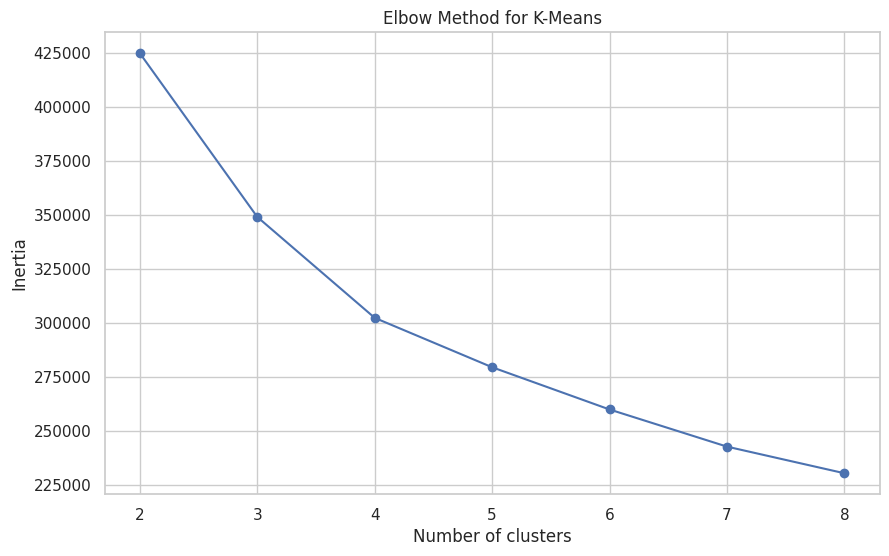

In [6]:
seg_features = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed', 'engagement_score',
    'monthly_value_sim', 'retention_months_sim', 'clv_sim'
]

seg_data = df[seg_features].copy()

scaler = StandardScaler()
seg_scaled = scaler.fit_transform(seg_data)

# Elbow method
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(seg_scaled)
    inertias.append(km.inertia_)

plt.plot(list(k_range), inertias, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

Silhouette Score: 0.3757310729060759
                      age    duration  campaign       pdays  previous  \
kmeans_segment                                                          
0               40.226549  208.877518  2.826465  999.000000  0.025258   
1               41.846204  315.911649  1.821990   17.709424  1.685209   
2               40.516311  766.924970  2.114176  997.528766  0.139976   
3               39.079019  207.876314  2.171954  999.000000  0.332814   

                emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  \
kmeans_segment                                                           
0                   1.121602       93.847034     -39.428064   4.820008   
1                  -2.095812       93.345082     -38.285537   0.983322   
2                  -0.585113       93.427788     -40.527758   2.891226   
3                  -2.007299       92.971548     -43.544025   1.218757   

                nr.employed  engagement_score  monthly_value_sim  \
kmeans_segm

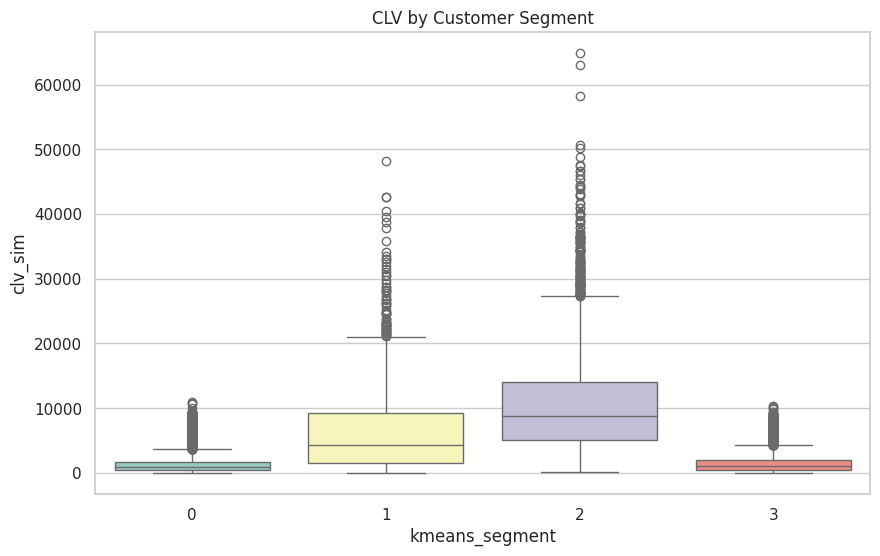

In [7]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['kmeans_segment'] = kmeans.fit_predict(seg_scaled)

sil_score = silhouette_score(seg_scaled, df['kmeans_segment'])
print("Silhouette Score:", sil_score)

segment_profile = df.groupby('kmeans_segment')[seg_features + ['y_bin']].mean()
print(segment_profile)

plt.figure(figsize=(10, 6))
sns.boxplot(x='kmeans_segment', y='clv_sim', data=df, palette='Set3')
plt.title("CLV by Customer Segment")
plt.show()

# 6. CHURN / RESPONSE PREDICTION

In [8]:
target_cls = 'y_bin'

drop_cols_cls = [
    'y', 'y_bin', 'clv_sim', 'monthly_value_sim',
    'retention_months_sim', 'discount_rate_sim',
    'churn_prob_sim', 'expected_lifetime_sim',
    'customer_segment', 'kmeans_segment'
]

X_cls = df.drop(columns=[c for c in drop_cols_cls if c in df.columns])
y_cls = df[target_cls]

cat_cols = X_cls.select_dtypes(include=['object']).columns.tolist()
num_cols = X_cls.select_dtypes(exclude=['object']).columns.tolist()

preprocessor_cls = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ]
)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

xgb_clf = Pipeline([
    ('prep', preprocessor_cls),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])

cat_clf = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    verbose=0,
    random_state=42
)

In [9]:
# XGBoost classifier
xgb_clf.fit(X_train_cls, y_train_cls)
y_pred_xgb = xgb_clf.predict(X_test_cls)
y_prob_xgb = xgb_clf.predict_proba(X_test_cls)[:, 1]

xgb_results = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test_cls, y_pred_xgb),
    "F1 Score": f1_score(y_test_cls, y_pred_xgb),
    "AUC": roc_auc_score(y_test_cls, y_prob_xgb)
}
print(xgb_results)
print(classification_report(y_test_cls, y_pred_xgb))



{'Model': 'XGBoost', 'Accuracy': 0.9996358339402768, 'F1 Score': 0.9983862291554599, 'AUC': np.float64(0.9999951353837445)}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7310
           1       1.00      1.00      1.00       928

    accuracy                           1.00      8238
   macro avg       1.00      1.00      1.00      8238
weighted avg       1.00      1.00      1.00      8238



In [10]:
# CatBoost needs raw categorical handling
X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

cat_features_idx = [X_cls.columns.get_loc(col) for col in cat_cols]

cat_clf.fit(X_train_cb, y_train_cb, cat_features=cat_features_idx)
y_pred_cat = cat_clf.predict(X_test_cb)
y_prob_cat = cat_clf.predict_proba(X_test_cb)[:, 1]

cat_results = {
    "Model": "CatBoost",
    "Accuracy": accuracy_score(y_test_cb, y_pred_cat),
    "F1 Score": f1_score(y_test_cb, y_pred_cat),
    "AUC": roc_auc_score(y_test_cb, y_prob_cat)
}
print(cat_results)
print(classification_report(y_test_cb, y_pred_cat))

{'Model': 'CatBoost', 'Accuracy': 0.9991502791939791, 'F1 Score': 0.9962264150943396, 'AUC': np.float64(0.9999942509080617)}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7310
           1       1.00      1.00      1.00       928

    accuracy                           1.00      8238
   macro avg       1.00      1.00      1.00      8238
weighted avg       1.00      1.00      1.00      8238



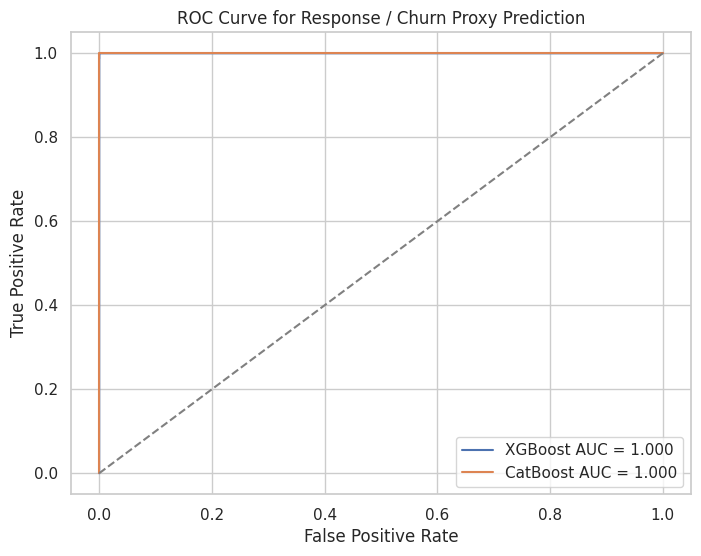

In [11]:
# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_cls, y_prob_xgb)
fpr_cat, tpr_cat, _ = roc_curve(y_test_cb, y_prob_cat)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost AUC = {xgb_results['AUC']:.3f}")
plt.plot(fpr_cat, tpr_cat, label=f"CatBoost AUC = {cat_results['AUC']:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Response / Churn Proxy Prediction")
plt.legend()
plt.show()

# 7. ENGAGEMENT PREDICTION

In [12]:
target_eng = 'engagement_score'

drop_cols_eng = [
    'engagement_score', 'clv_sim', 'monthly_value_sim',
    'retention_months_sim', 'discount_rate_sim',
    'churn_prob_sim', 'expected_lifetime_sim',
    'customer_segment', 'kmeans_segment'
]

X_eng = df.drop(columns=[c for c in drop_cols_eng if c in df.columns])
y_eng = df[target_eng]

cat_cols_eng = X_eng.select_dtypes(include=['object']).columns.tolist()
num_cols_eng = X_eng.select_dtypes(exclude=['object']).columns.tolist()

preprocessor_eng = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols_eng),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols_eng)
    ]
)

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng, y_eng, test_size=0.2, random_state=42
)

xgb_eng = Pipeline([
    ('prep', preprocessor_eng),
    ('model', XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

xgb_eng.fit(X_train_eng, y_train_eng)
y_pred_eng = xgb_eng.predict(X_test_eng)

eng_results = {
    "Model": "XGBoost Regressor",
    "RMSE": np.sqrt(mean_squared_error(y_test_eng, y_pred_eng)),
    "MAE": mean_absolute_error(y_test_eng, y_pred_eng),
    "R2": r2_score(y_test_eng, y_pred_eng)
}
print(eng_results)

{'Model': 'XGBoost Regressor', 'RMSE': np.float64(0.6863367187045735), 'MAE': 0.11432928167361313, 'R2': 0.9911977252881492}


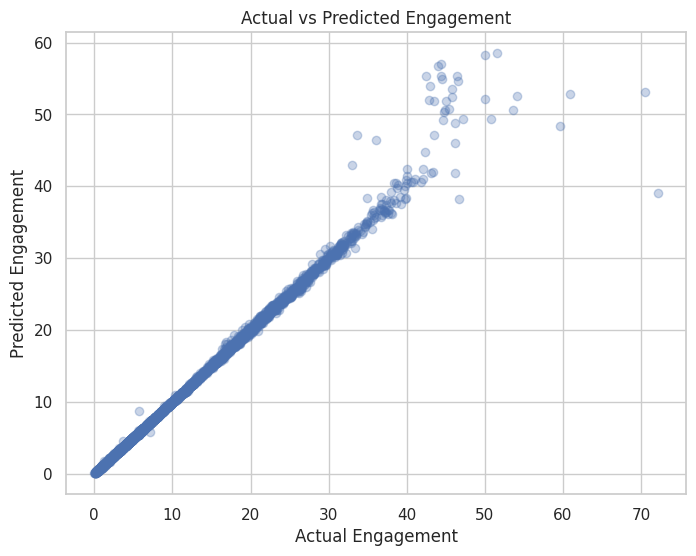

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_eng, y_pred_eng, alpha=0.3)
plt.xlabel("Actual Engagement")
plt.ylabel("Predicted Engagement")
plt.title("Actual vs Predicted Engagement")
plt.show()

# 8. CLV PREDICTION

In [14]:
target_clv = 'clv_sim'

drop_cols_clv = [
    'clv_sim', 'monthly_value_sim', 'retention_months_sim',
    'discount_rate_sim', 'expected_lifetime_sim'
]

X_clv = df.drop(columns=[c for c in drop_cols_clv if c in df.columns])
y_clv = df[target_clv]

cat_cols_clv = X_clv.select_dtypes(include=['object']).columns.tolist()
num_cols_clv = X_clv.select_dtypes(exclude=['object']).columns.tolist()

preprocessor_clv = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols_clv),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols_clv)
    ]
)

X_train_clv, X_test_clv, y_train_clv, y_test_clv = train_test_split(
    X_clv, y_clv, test_size=0.2, random_state=42
)

xgb_clv = Pipeline([
    ('prep', preprocessor_clv),
    ('model', XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

xgb_clv.fit(X_train_clv, y_train_clv)
y_pred_clv = xgb_clv.predict(X_test_clv)

clv_results = {
    "Model": "XGBoost Regressor",
    "RMSE": np.sqrt(mean_squared_error(y_test_clv, y_pred_clv)),
    "MAE": mean_absolute_error(y_test_clv, y_pred_clv),
    "MAPE": mean_absolute_percentage_error(y_test_clv, y_pred_clv),
    "R2": r2_score(y_test_clv, y_pred_clv)
}
print(clv_results)

{'Model': 'XGBoost Regressor', 'RMSE': np.float64(2652.708672956103), 'MAE': 1317.144447528203, 'MAPE': 1.6214183685341064, 'R2': 0.5312132766523048}


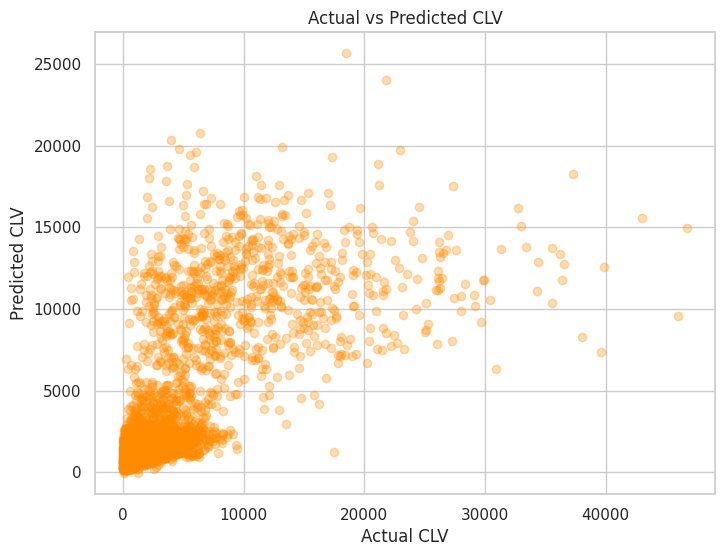

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_clv, y_pred_clv, alpha=0.3, color='darkorange')
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Actual vs Predicted CLV")
plt.show()

# 9. FEATURE IMPORTANCE FOR CLV MODEL

                          feature  importance
68                           y_no    0.440640
10                          y_bin    0.304449
14                 kmeans_segment    0.028588
13                 churn_prob_sim    0.015755
12               customer_segment    0.009303
19                 job_management    0.007258
37    education_university.degree    0.006346
50                      month_apr    0.006008
23                    job_student    0.005928
16                job_blue-collar    0.005917
36  education_professional.course    0.005144
29                 marital_single    0.004781
67               poutcome_success    0.004260
63                day_of_week_tue    0.004225
51                      month_aug    0.004024


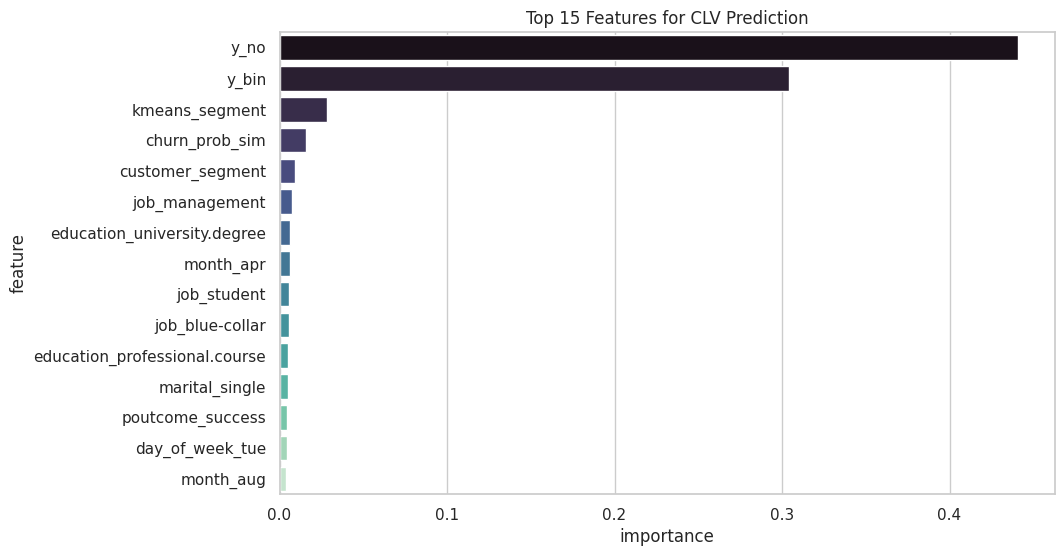

In [16]:
prep_fit = preprocessor_clv.fit(X_train_clv)
X_train_trans = prep_fit.transform(X_train_clv)

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train_trans, y_train_clv)

ohe = prep_fit.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(cat_cols_clv)
feature_names = num_cols_clv + list(cat_feature_names)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False).head(15)

print(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='mako')
plt.title("Top 15 Features for CLV Prediction")
plt.show()



# 10. RESULTS TABLES FOR PAPER

In [17]:
classification_results = pd.DataFrame([xgb_results, cat_results])
print("\nClassification Results")
print(classification_results)

regression_results = pd.DataFrame([
    {"Task": "Engagement Prediction", **eng_results},
    {"Task": "CLV Prediction", **clv_results}
])
print("\nRegression Results")
print(regression_results)


Classification Results
      Model  Accuracy  F1 Score       AUC
0   XGBoost  0.999636  0.998386  0.999995
1  CatBoost  0.999150  0.996226  0.999994

Regression Results
                    Task              Model         RMSE          MAE  \
0  Engagement Prediction  XGBoost Regressor     0.686337     0.114329   
1         CLV Prediction  XGBoost Regressor  2652.708673  1317.144448   

         R2      MAPE  
0  0.991198       NaN  
1  0.531213  1.621418  


# 11. SEGMENT-LEVEL MARKETING INTERPRETATION TABLE

In [18]:
segment_summary = df.groupby('kmeans_segment').agg({
    'age': 'mean',
    'duration': 'mean',
    'campaign': 'mean',
    'engagement_score': 'mean',
    'clv_sim': 'mean',
    'y_bin': 'mean'
}).reset_index()

segment_summary = segment_summary.rename(columns={
    'y_bin': 'conversion_rate'
})

print(segment_summary)

   kmeans_segment        age    duration  campaign  engagement_score  \
0               0  40.226549  208.877518  2.826465          6.028488   
1               1  41.846204  315.911649  1.821990         15.976230   
2               2  40.516311  766.924970  2.114176         26.218562   
3               3  39.079019  207.876314  2.171954          6.902294   

        clv_sim  conversion_rate  
0   1314.212784         0.003345  
1   6508.718626         0.636780  
2  10630.825261         0.847272  
3   1513.653446         0.070358  


# 12. SAVE OUTPUTS

In [19]:
classification_results.to_csv("classification_results.csv", index=False)
regression_results.to_csv("regression_results.csv", index=False)
segment_summary.to_csv("segment_summary.csv", index=False)
importance_df.to_csv("clv_feature_importance.csv", index=False)